# Ceridwen spectroscopy test: LEGA-C M1_210210

- fit the same passive galaxy using LEGA-C spectroscopy
- resolve absorption features with the alpha-enhanced C3K_HR grid

## 1. Imports and reproducibility

- use Ceridwen's alpha-enhanced stellar population model
- record one seed for every stochastic calculation

In [1]:
import os
from pathlib import Path

import astropy.units as u
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.constants import c
from astropy.io import fits
from astropy.table import Table
from scipy.stats import entropy
from specutils.utils.wcs_utils import air_to_vac

from ceridwen.cosmology import age_gyr
from ceridwen.csp import CSPBasis_afe
from ceridwen.likelihood import (
    DiagonalGaussianLikelihood,
    DiagonalNoiseModel,
    MultiObservationLikelihood,
)
from ceridwen.model import SedModel, logsfr_ratios_to_sfh
from ceridwen.observation import Spectrum
from ceridwen.sampler import run_sampler
from ceridwen.sampler.nuts import BlackJAXNUTSAdapter
from ceridwen.sampler.priors import Uniform
from ceridwen.ssps import SSPDataAfe

jax.config.update("jax_enable_x64", True)

SEED = 20260811
QUICK_TEST = os.environ.get("CERIDWEN_NOTEBOOK_QUICK") == "1"
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

print(f"JAX devices: {jax.devices()}")
print(f"quick test: {QUICK_TEST}")
print(f"project root: {PROJECT_ROOT}")

JAX devices: [CpuDevice(id=0)]
quick test: False
project root: /Users/liuhao/Downloads/Astro project


## 2. Load the matched LEGA-C catalogues

- reuse the photometric match defining notebook 06's sample

In [2]:
LEGAC_PATH = PROJECT_ROOT / "data/raw/legac_dr2/legaCdr2.fits.gz"
PHOT_PATH = (
    PROJECT_ROOT
    / "data/raw/cosmos2015/cosmos2015_legac_dr2_photometry_1arcsec.fits"
)
SPECTRA_DIR = PROJECT_ROOT / "data/raw/legac_dr2/sp"

In [3]:
legac = Table.read(LEGAC_PATH)
phot = Table.read(PHOT_PATH)

assert len(legac) == 1988
assert len(np.unique(phot["LEGAC_INDEX"])) == len(phot)
assert np.max(phot["MATCH_SEP_ARCSEC"]) < 1.0
assert "uJy" in phot["Fipap3"].unit.to_string()

print(f"LEGA-C DR2 rows: {len(legac)}")
print(f"COSMOS2015 counterparts: {len(phot)}")
print(f"maximum retained separation: {np.max(phot['MATCH_SEP_ARCSEC']):.3f} arcsec")

LEGA-C DR2 rows: 1988
COSMOS2015 counterparts: 1982
maximum retained separation: 0.925 arcsec


## 3. Rebuild the passive sample

- require primary scientific-use LEGA-C spectra
- apply earlier NUVrJ and emission-line cuts
- require clean photometric footprint flags

In [4]:
legac_frame = legac.to_pandas()
for text_column in ["SPECT_ID", "Filename"]:
    legac_frame[text_column] = legac_frame[text_column].map(
        lambda value: value.decode() if isinstance(value, bytes) else value
    )
phot_frame = phot.to_pandas().set_index("LEGAC_INDEX")
phot_columns = [
    "Area", "Sat", "Cfl", "Deep", "Flag", "E(B-V)", "NUVMag", "RMag",
    "JMag", "Fuap3", "e_Fuap3", "FBap3", "e_FBap3", "FVap3", "e_FVap3",
    "Frap3", "e_Frap3", "Fipap3", "e_Fipap3", "Fzppap3", "e_Fzppap3",
    "FYap3", "e_FYap3", "FJap3", "e_FJap3", "FHap3", "e_FHap3",
    "FKsap3", "e_FKsap3", "F3.6um", "e_F3.6um", "F4.5um", "e_F4.5um",
]
parent = legac_frame.join(phot_frame[phot_columns], how="inner")

quality = (
    (parent["f_use"] == 1)
    & (parent["f_ppxf"] == 0)
    & (parent["f_z"] == 0)
    & (parent["f_int"] == 0)
    & (parent["SN"] > 0)
    & (parent["z"] >= 0.6)
    & (parent["z"] < 1.0)
)
valid_rest_magnitudes = (parent[["NUVMag", "RMag", "JMag"]] > -40).all(axis=1)
parent = parent[quality & valid_rest_magnitudes].copy()

nuv_r = parent["NUVMag"] - parent["RMag"]
r_j = parent["RMag"] - parent["JMag"]
nuvrj = (nuv_r > 3 * r_j + 1) & (nuv_r > 3.1)
photometric_passive = parent[nuvrj]

oii_ew = photometric_passive["OII_3727_EW"]
weak_oii = photometric_passive[(oii_ew > -5) | oii_ew.isna()]
oii_significance = (weak_oii["OII_3727_EW"] / weak_oii["OII_3727_EW_err"]).abs()
oiii_significance = (
    weak_oii["OIII_5007_EW"] / weak_oii["OIII_5007_EW_err"]
).abs()
bona_fide_passive = weak_oii[
    ~((oii_significance >= 3) | (oiii_significance >= 3))
]

clean_photometry = (
    (bona_fide_passive["Area"] == 0)
    & (bona_fide_passive["Sat"] == 0)
    & (bona_fide_passive["Cfl"] == 1)
    & (bona_fide_passive["Flag"] == 0)
)
usable_passive = bona_fide_passive[clean_photometry]

selection_counts = pd.Series(
    {
        "matched primary spectra": len(parent),
        "NUVrJ passive": len(photometric_passive),
        "weak [OII]": len(weak_oii),
        "bona-fide passive": len(bona_fide_passive),
        "clean twelve-band photometry": len(usable_passive),
    }
)
display(selection_counts.to_frame("count"))

,count
matched primary spectra,1328
NUVrJ passive,609
weak [OII],454
bona-fide passive,349
clean twelve-band photometry,194


## 4. Load the same high-S/N test galaxy

- fix redshift and velocity dispersion from LEGA-C

In [5]:
def load_spectrum(filename):
    if isinstance(filename, bytes):
        filename = filename.decode()
    with fits.open(SPECTRA_DIR / filename) as hdulist:
        spectrum = hdulist[1].data
        instrument_resolution = float(hdulist[0].header["SPEC_RES"])
    wave, flux, error, quality_flag = (
        spectrum[column][0] for column in ("WAVE", "FLUX", "ERR", "QUAL")
    )
    good = (quality_flag == 0) & (error > 0) & np.isfinite(flux)
    return wave, flux, error, good, instrument_resolution


target_rows = usable_passive[usable_passive["SPECT_ID"] == "M1_210210"]
assert len(target_rows) == 1
galaxy = target_rows.iloc[0]
wave_air, flux_dr2, error_dr2, good_pixel, instrument_fwhm_resolution = (
    load_spectrum(galaxy["Filename"])
)

z_catalog = float(galaxy["z"])
observed_break = 4000 * (1 + z_catalog)
assert wave_air[good_pixel].min() < observed_break < wave_air[good_pixel].max()

print(f"{galaxy['SPECT_ID']}  z={galaxy['z']:.4f}")
print(f"catalogue S/N={galaxy['SN']:.1f}")
sigma_star = float(galaxy["SIGMA_STARS_PRIME"])
print(f"fixed sigma*={sigma_star:.1f} km/s")
print(f"instrument FWHM resolving power={instrument_fwhm_resolution:.0f}")
print(
    f"good spectral coverage: {wave_air[good_pixel].min():.0f}-"
    f"{wave_air[good_pixel].max():.0f} angstrom"
)

M1_210210  z=0.6542
catalogue S/N=62.2
fixed sigma*=259.5 km/s
good spectral coverage: 6190-8633 angstrom


## 5. Load the alpha-enhanced stellar grid

- load the local Kroupa C3K high-resolution grid

In [6]:
grid_path = PROJECT_ROOT / "ceridwen/amist_c3k_hr_krou_afe.h5"
ssp = SSPDataAfe.load(grid_path)
ssp.display()

universe_age = float(age_gyr(z_catalog))
lookback_template = np.array([0.0, 0.03, 0.1, 0.3, 1.0, 3.0, 5.0, universe_age])

assert ssp.ssp_flux.shape[0] == 5
assert lookback_template[-1] <= 10 ** float(ssp.ssp_lg_age_gyr.max())

print(f"catalogue-redshift universe age: {universe_age:.3f} Gyr")
print(f"SFH nodes: {lookback_template}")

SSPDataAfe
------------------------------------------------------------------
provenance
  isochrones (isoc_type)   : mist
  spectral library         : c3k_lr
  IMF (imf_type)           : 1
  FSPS version             : 0.4.9.dev16+gc18b87021
  schema version           : 2.0
  recorded wave_min/max    : 99.99999999999994 / 99595854.86327352
  build kwargs             : {'imf_type': 1}
grids
  [alpha/Fe]               :    5 pts   [-0.2  0.   0.2  0.4  0.6]
  metallicity  log10 Z     :   13 pts   [-4.233, -1.233]  (absolute TOTAL Z, NOT Z/Zsun, NOT [Fe/H])
  age          log10(Gyr)  :  107 pts   [-4.000, +1.300]  = [0.0001, 20] Gyr
  wavelength   Angstrom    : 1936 pts   [100.0, 99595854.9]
  flux (n_afe,n_met,n_age,n_wave): (5, 13, 107, 1936)  [L_sun Hz^-1 M_sun^-1]  float64  102.7 MB


catalogue-redshift universe age: 7.566 Gyr
SFH nodes: [0.         0.03       0.1        0.3        1.         3.
 5.         7.56620799]


## 6. Build the native-resolution spectrum

- retain every valid native LEGA-C spectral pixel
- apply the catalogue instrument resolution and stellar dispersion
- mask invalid, emission-line, and telluric regions
- initialize Ceridwen's sampled calibration floor at three percent

Spectrum (spectrum)
  ndata         : 68
  ndof          : 52
  wavelength    : 6191.4 – 8648.0 Å
  resolution    : none
  smoothtype    : None
  sigma_losvd   : 259.5 km/s
  logify        : False
  calibration   : none
  sky           : none
  noise_floor   : 0.0000
  noise model   : none
  masked pixels : 16 / 68

  i              λ [Å]            flux               σ   mask
  -----------------------------------------------------------
  0            6191.41      0.0000e+00      1.0000e+00  False
  1            6222.37      8.4968e-29      5.4679e-31   True
  2            6253.48      1.0300e-28      5.1879e-31   True
  3            6284.75      0.0000e+00      1.0000e+00  False
  4            6316.17      0.0000e+00      1.0000e+00  False
  5            6347.76      6.8531e-29      4.1767e-31   True
  6            6379.49      0.0000e+00      1.0000e+00  False
  7            6411.39      9.6614e-29      4.0638e-31   True
  8            6443.45      1.0839e-28      4.0591e-31   True


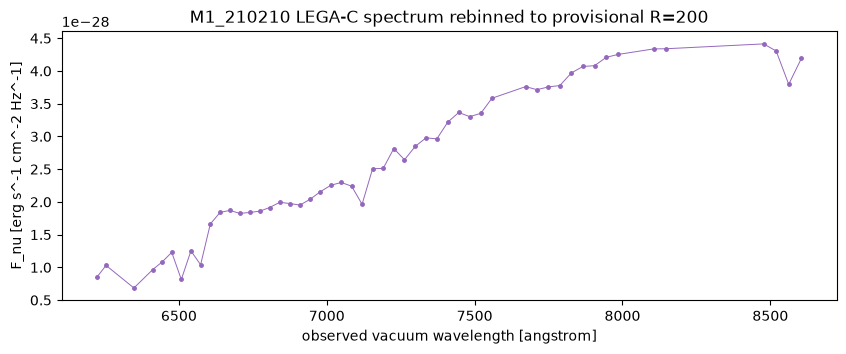

In [7]:
DR2_FLUX_UNIT = 1e-19 * u.erg / u.s / u.cm**2 / u.AA
SPECTRUM_CALIBRATION_INIT = 0.03
FWHM_TO_SIGMA = 2 * np.sqrt(2 * np.log(2))
C3K_FWHM_RESOLUTION = 3000.0
REST_EMISSION_LINES = [3726.0, 3728.8, 4861.3, 4958.9, 5006.8]


def flam_to_fnu_cgs(values, wavelength):
    f_lambda = values * DR2_FLUX_UNIT
    return f_lambda.to_value(
        u.erg / u.s / u.cm**2 / u.Hz,
        equivalencies=u.spectral_density(wavelength * u.AA),
    )


wave_vacuum = air_to_vac(wave_air * u.AA).to_value(u.AA)
spectrum_native = flam_to_fnu_cgs(flux_dr2, wave_vacuum)
uncertainty_native = flam_to_fnu_cgs(error_dr2, wave_vacuum)
native_valid = (
    good_pixel
    & np.isfinite(spectrum_native)
    & np.isfinite(uncertainty_native)
    & (uncertainty_native > 0)
)
spectrum_wave = wave_vacuum
spectrum_flux = np.nan_to_num(spectrum_native, nan=0.0)
spectrum_uncertainty = np.where(
    native_valid, uncertainty_native, 1.0
)
spectrum_obs = Spectrum(
    wavelength=spectrum_wave,
    flux=spectrum_flux,
    uncertainty=spectrum_uncertainty,
    mask=native_valid,
    resolution=instrument_fwhm_resolution * FWHM_TO_SIGMA,
    smoothtype="R",
    inres=c.to_value(u.km / u.s) / (C3K_FWHM_RESOLUTION * FWHM_TO_SIGMA),
    sigma_losvd=sigma_star,
    name="spectrum",
)
spectrum_obs.mask_lines(
    REST_EMISSION_LINES,
    dv=1500.0,
    zred=z_catalog,
)
telluric_vacuum = air_to_vac(np.array([7590.0, 7660.0]) * u.AA).to_value(u.AA)
spectrum_obs.mask_wavelength_range(*telluric_vacuum)
spectrum_mask = np.asarray(spectrum_obs.mask)

grid_wave = np.asarray(ssp.ssp_wave)
grid_resolving_power = np.median(grid_wave[:-1] / np.diff(grid_wave))
assert np.isclose(grid_resolving_power, 6000.0, rtol=0.01)
assert instrument_fwhm_resolution < C3K_FWHM_RESOLUTION
assert spectrum_obs.ndof > 3000

spectrum_obs.display()
print(f"native good pixels: {good_pixel.sum()}")
print(f"C3K_HR wavelength-grid sampling: R={grid_resolving_power:.0f}")
print(f"C3K_HR optical FWHM resolution: R={C3K_FWHM_RESOLUTION:.0f}")
print(f"native LEGA-C pixels: {len(spectrum_wave)}")
print(f"fitted native pixels: {spectrum_obs.ndof}")
print(f"fixed stellar velocity dispersion: {sigma_star:.1f} km/s")
print("calibration-floor prior: 1%-10%; initialized at 3%")

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.errorbar(
    spectrum_wave[spectrum_mask],
    spectrum_flux[spectrum_mask],
    yerr=spectrum_uncertainty[spectrum_mask],
    fmt="-",
    lw=0.5,
    color="tab:purple",
)
ax.set(
    xlabel="observed vacuum wavelength [angstrom]",
    ylabel="F_nu [erg s^-1 cm^-2 Hz^-1]",
)
ax.set_title("M1_210210 native LEGA-C spectrum")
plt.show()

## 7. Define the spectroscopic Ceridwen model

- reuse notebook 06's stellar-population parameterization
- fix catalogue redshift and velocity dispersion

In [8]:
N_RATIOS = len(lookback_template) - 1
Z_BOUNDS = (
    float(ssp.ssp_lgmet.min()) + 1e-4,
    float(ssp.ssp_lgmet.max()) - 1e-4,
)
AFE_BOUNDS = (float(ssp.ssp_afe.min()), float(ssp.ssp_afe.max()))
ZRED_BOUNDS = (z_catalog - 0.001, z_catalog + 0.001)
FIXED_DUST_INDEX = -0.7


def make_csp(track_redshift_age, sigma_losvd):
    theta = {
        "lookback_time": jnp.asarray(lookback_template),
        "sfh": jnp.ones(len(lookback_template)),
        "Z": jnp.array([-1.85]),
        "afe": jnp.array([0.2]),
        "diffuse_tau_kc": jnp.array([0.2]),
        "diffuse_dust_index": jnp.array([FIXED_DUST_INDEX]),
    }
    return CSPBasis_afe(
        ssp,
        theta=theta,
        zh_const=True,
        sfh_interp="step",
        add_dust=False,
        add_diffuse_dust=True,
        add_dust_emission=False,
        add_igm=False,
        sigma_losvd_kms=sigma_losvd,
        track_zred_age=track_redshift_age,
        verbose=False,
    )


def make_model(observation, free_redshift, sigma_losvd):
    csp = make_csp(free_redshift, sigma_losvd)
    template = jnp.asarray(lookback_template)

    def lookback_from_redshift(free_theta):
        redshift = jnp.ravel(free_theta["zred"])[0]
        return template * age_gyr(redshift) / template[-1]

    def sfh_fixed_redshift(free_theta):
        return logsfr_ratios_to_sfh(
            free_theta["logsfr_ratios"],
            sfh_times_yr=np.asarray(csp.sfh_times),
        )

    def sfh_free_redshift(free_theta):
        times = lookback_from_redshift(free_theta) * 1e9
        return logsfr_ratios_to_sfh(
            free_theta["logsfr_ratios"], sfh_times_yr=times
        )

    transforms = {
        "sfh": sfh_free_redshift if free_redshift else sfh_fixed_redshift,
        "diffuse_dust_index": lambda free_theta: jnp.array(
            [FIXED_DUST_INDEX]
        ),
    }
    if free_redshift:
        transforms["lookback_time"] = lookback_from_redshift

    priors = {
        "logsfr_ratios": Uniform(low=-3.0, high=3.0),
        "Z": Uniform(low=Z_BOUNDS[0], high=Z_BOUNDS[1]),
        "afe": Uniform(low=AFE_BOUNDS[0], high=AFE_BOUNDS[1]),
        "logmass": Uniform(low=8.0, high=13.0),
        "diffuse_tau_kc": Uniform(low=0.0, high=2.0),
        "log_f_calib": Uniform(low=np.log(0.01), high=np.log(0.10)),
    }
    free_param_init = {
        "logsfr_ratios": jnp.zeros(N_RATIOS),
        "logmass": jnp.array([11.0]),
        "log_f_calib": jnp.array([np.log(SPECTRUM_CALIBRATION_INIT)]),
    }
    bounds = {
        "logsfr_ratios": (-3.0, 3.0),
        "Z": Z_BOUNDS,
        "afe": AFE_BOUNDS,
        "logmass": (8.0, 13.0),
        "diffuse_tau_kc": (0.0, 2.0),
        "log_f_calib": (np.log(0.01), np.log(0.10)),
    }
    if free_redshift:
        priors["zred"] = Uniform(low=ZRED_BOUNDS[0], high=ZRED_BOUNDS[1])
        free_param_init["zred"] = jnp.array([z_catalog])
        bounds["zred"] = ZRED_BOUNDS

    model = SedModel(
        csp,
        observations=[observation],
        priors=priors,
        transforms=transforms,
        free_param_init=free_param_init,
        zred=z_catalog,
    )
    return model, csp, bounds

## 8. Verify the initial spectral prediction

- match the slit normalization before sampling

In [9]:
spectrum_model, spectrum_csp, spectrum_bounds = make_model(
    spectrum_obs, free_redshift=False, sigma_losvd=0.0
)

initial_prediction = np.asarray(
    spectrum_model.predict(spectrum_model.theta_init)["spectrum"]
)
active = spectrum_mask & (initial_prediction > 0) & (spectrum_flux > 0)
normalization_shift = np.median(
    np.log10(spectrum_flux[active] / initial_prediction[active])
)
spectrum_model.theta_init["logmass"] = (
    spectrum_model.theta_init["logmass"] + normalization_shift
)
initial_prediction = np.asarray(
    spectrum_model.predict(spectrum_model.theta_init)["spectrum"]
)
spectrum_csp.check_param_ranges(
    spectrum_model.apply_transforms(spectrum_model.theta_init)
)

assert initial_prediction.shape == spectrum_flux.shape
assert np.all(np.isfinite(initial_prediction))

print(f"spectrum redshift fixed at {z_catalog:.4f}")
print(f"spectrum sigma* fixed at {sigma_star:.1f} km/s")
print(
    "initial slit-normalization logmass: "
    f"{float(spectrum_model.theta_init['logmass'][0]):.3f}"
)

Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)


spectrum redshift fixed at 0.6542
spectrum sigma* fixed at 259.5 km/s
initial slit-normalization logmass: 11.032


## 9. Run the spectroscopic NUTS fit

- use four chains for the reference spectral test

In [10]:
if QUICK_TEST:
    spectrum_settings = {
        "num_warmup": 8,
        "num_samples": 8,
        "num_chains": 2,
        "target_acceptance": 0.9,
        "vi_steps": 20,
    }
else:
    spectrum_settings = {
        "num_warmup": 1000,
        "num_samples": 2000,
        "num_chains": 4,
        "target_acceptance": 0.95,
        "vi_steps": 1500,
    }

adapter = BlackJAXNUTSAdapter(
    num_warmup=spectrum_settings["num_warmup"],
    num_samples=spectrum_settings["num_samples"],
    num_chains=spectrum_settings["num_chains"],
    target_acceptance=spectrum_settings["target_acceptance"],
    max_num_doublings=8,
    bounds=spectrum_bounds,
    vi="tril",
    vi_kwargs={"num_steps": spectrum_settings["vi_steps"]},
    verbose=True,
)
likelihood = MultiObservationLikelihood(
    keys=(spectrum_obs.name,),
    likelihoods=(
        DiagonalGaussianLikelihood(
            noise_model=DiagonalNoiseModel(use_fractional=True)
        ),
    ),
)
spectrum_result = run_sampler(
    spectrum_model,
    likelihood,
    adapter,
    jax.random.PRNGKey(SEED),
)
print(spectrum_result.summary())

BlackJAX NUTS (VI-preconditioned)  |  n_dims=12  num_warmup=1000  num_samples=2000  num_chains=4  dense_mass=False  vi='tril'


  [vi] training tril: D=12  batch=16  steps=1500  lr0=0.01  optax=yes


    iter     1/1500  -ELBO = +5.444e+03
    iter     2/1500  -ELBO = +9.957e+03
    iter     3/1500  -ELBO = +4.944e+03


    iter   250/1500  -ELBO = -2.945e+03


    iter   500/1500  -ELBO = -3.162e+03


...

<div><progress max="1000" value="1000"></progress> 100.00% [1000/1000 00:00&lt;?]</div>

    Adapted step size: 0.0068
    Warmup wall time:  629.6 s



  Available devices: 1  |  Chains: 4  |  Strategy: sequential scan



  Whitened-NUTS timing:
    VI train: 77.28 s  (1500 iters)
    Warmup:   629.60 s  (1000 steps, eps=0.0068)
    Sample:   5081.18 s  (4 x 2000 draws)

  Convergence diagnostics:
  Parameter                     R-hat       ESS
  ---------------------------------------------
  Z                            1.0021      1723
  afe                          1.0014      1761
  diffuse_tau_kc               1.0020      1120
  logsfr_ratios[0]             1.0023      1357
  logsfr_ratios[1]             1.0011      1562
  logsfr_ratios[2]             1.0000      1436
  logsfr_ratios[3]             1.0051      1383
  logsfr_ratios[4]             1.0057       623
  logsfr_ratios[5]             1.0044       556
  logsfr_ratios[6]             1.0046      1546
  logmass                      1.0030       810
  log_f_calib                  1.0001      8000


blackjax.nuts+vi  |  n_samples=8000  ln Z = n/a  |  n_like = 12000  |  wall = 5719.9 s


## 10. Check convergence and information gain

- require zero divergences and stable four-chain mixing

In [11]:
def diagnostic_table(result, model, bounds):
    chains = [np.asarray(chain) for chain in result.raw["per_chain_constrained"]]
    rows = []
    column = 0
    for name, parameter_template in model.theta_init.items():
        size = int(np.size(parameter_template))
        for component in range(size):
            values = [chain[:, column + component] for chain in chains]
            posterior = np.concatenate(values)
            low, high = bounds[name]
            counts, _ = np.histogram(posterior, bins=30, range=(low, high))
            probabilities = (counts + 1e-12) / np.sum(counts + 1e-12)
            uniform = np.full(30, 1 / 30)
            rows.append(
                {
                    "parameter": name if size == 1 else f"{name}[{component}]",
                    "R-hat": BlackJAXNUTSAdapter._rhat(values),
                    "ESS": BlackJAXNUTSAdapter._ess(values),
                    "KL posterior||prior": entropy(probabilities, uniform),
                }
            )
        column += size
    return pd.DataFrame(rows)


spectrum_diagnostics = diagnostic_table(
    spectrum_result,
    spectrum_model,
    spectrum_bounds,
)
display(spectrum_diagnostics)

spectrum_converged = (
    spectrum_result.raw["total_divergences"] == 0
    and spectrum_diagnostics["R-hat"].max() <= 1.05
    and spectrum_diagnostics["ESS"].min() >= 200
)
spectrum_status = (
    "diagnostics passed" if spectrum_converged else "exploratory: diagnostics failed"
)
print("spectrum:", spectrum_status)
print("spectrum divergences:", spectrum_result.raw["total_divergences"])

,parameter,R-hat,ESS,KL posterior||prior
0,Z,1.002139,1722.716948,1.590261
1,afe,1.001418,1760.873062,0.486116
2,diffuse_tau_kc,1.001988,1119.601907,1.270656
3,logsfr_ratios[0],1.002286,1357.309797,0.043564
4,logsfr_ratios[1],1.001135,1562.293120,0.145362
5,logsfr_ratios[2],0.999962,1435.874888,0.176607
6,logsfr_ratios[3],1.005092,1382.934670,0.078694
7,logsfr_ratios[4],1.005739,623.470363,0.051680
8,logsfr_ratios[5],1.004446,556.307120,0.074791
9,logsfr_ratios[6],1.004560,1546.154323,0.011091


spectrum: diagnostics passed
spectrum divergences: 0


## 11. Inspect the posterior spectrum

- compare fitted bins, pulls, and calibration structure

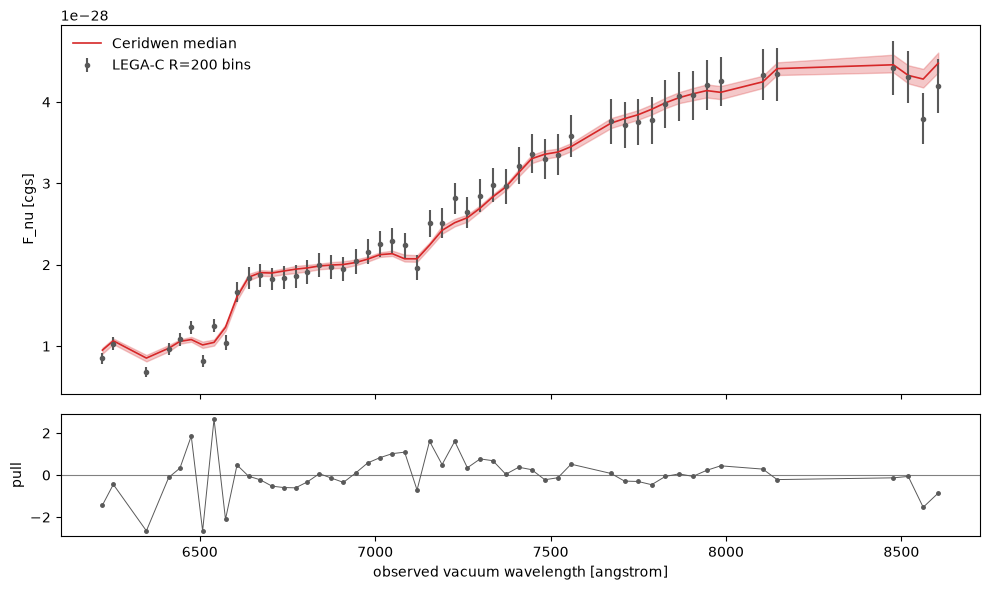

sampled calibration floor: 7.40%
spectrum chi2/bin: 0.92
post-hoc calibrated chi2/bin: 0.79
post-hoc Chebyshev coefficients: [ 0.97201263  0.00853384 -0.05371384  0.01292204]


In [ ]:
def posterior_batch(result, model, count):
    total = len(next(iter(result.samples.values())))
    indices = np.linspace(0, total - 1, min(count, total), dtype=int)
    batch = {}
    for name, parameter_template in model.theta_init.items():
        values = np.asarray(result.samples[name])[indices]
        if np.shape(parameter_template) == (1,) and values.ndim == 1:
            values = values[:, None]
        batch[name] = jnp.asarray(values)
    return batch


spectrum_predictions = np.asarray(
    spectrum_model.predict_vmap(
        posterior_batch(spectrum_result, spectrum_model, 200)
    )["spectrum"]
)
spec_q16, spec_q50, spec_q84 = np.percentile(
    spectrum_predictions, [16, 50, 84], axis=0
)
calibration_fraction = float(
    np.exp(np.median(np.asarray(spectrum_result.samples["log_f_calib"])))
)
effective_uncertainty = np.hypot(
    spectrum_uncertainty, calibration_fraction * np.abs(spec_q50)
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 6),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True,
)
axes[0].errorbar(
    spectrum_wave[spectrum_mask],
    spectrum_flux[spectrum_mask],
    yerr=effective_uncertainty[spectrum_mask],
    fmt="-",
    lw=0.5,
    color="0.35",
    label="LEGA-C native fitted pixels",
)
axes[0].plot(
    spectrum_wave[spectrum_mask],
    spec_q50[spectrum_mask],
    color="tab:red",
    lw=1.2,
    label="Ceridwen median",
)
axes[0].fill_between(
    spectrum_wave[spectrum_mask],
    spec_q16[spectrum_mask],
    spec_q84[spectrum_mask],
    color="tab:red",
    alpha=0.25,
)
axes[0].set(ylabel="F_nu [cgs]")
axes[0].legend(frameon=False)
axes[1].axhline(0, color="0.5", lw=0.8)
axes[1].plot(
    spectrum_wave[spectrum_mask],
    (
        spectrum_flux[spectrum_mask] - spec_q50[spectrum_mask]
    ) / effective_uncertainty[spectrum_mask],
    lw=0.45,
    color="0.35",
)
axes[1].set(xlabel="observed vacuum wavelength [angstrom]", ylabel="pull")
plt.tight_layout()
plt.show()

spectrum_chi2 = np.sum(
    (
        (spectrum_flux[spectrum_mask] - spec_q50[spectrum_mask])
        / effective_uncertainty[spectrum_mask]
    )
    ** 2
)
calibration_coefficients, calibrated_median = (
    spectrum_obs.fit_polynomial_calibration(spec_q50, order=3)
)
calibrated_effective_uncertainty = np.hypot(
    spectrum_uncertainty,
    calibration_fraction * np.abs(np.asarray(calibrated_median)),
)
calibrated_chi2 = np.sum(
    (
        (spectrum_flux[spectrum_mask] - np.asarray(calibrated_median)[spectrum_mask])
        / calibrated_effective_uncertainty[spectrum_mask]
    )
    ** 2
)
print(f"sampled calibration floor: {100 * calibration_fraction:.2f}%")
print(f"spectrum chi2/bin: {spectrum_chi2 / spectrum_obs.ndof:.2f}")
print(f"post-hoc calibrated chi2/bin: {calibrated_chi2 / spectrum_obs.ndof:.2f}")
print(f"post-hoc Chebyshev coefficients: {calibration_coefficients}")

## Full native-spectrum comparison

- show every native pixel used by the likelihood
- compare high-resolution absorption structure and residuals

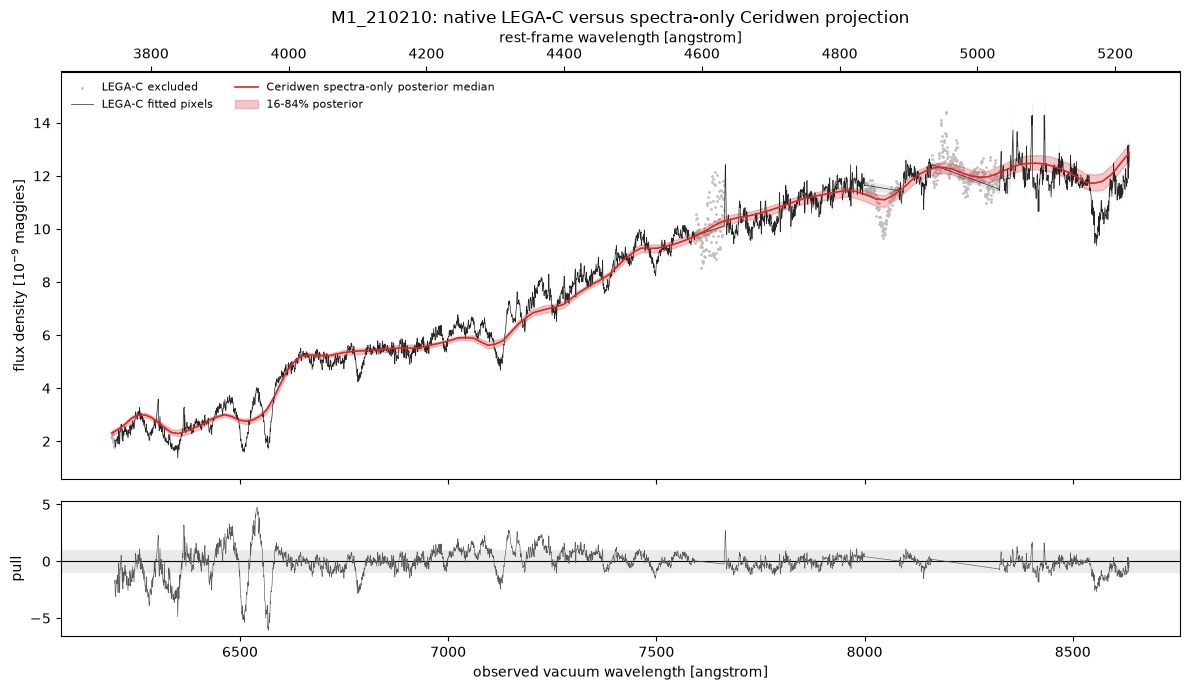

native valid pixels shown: 4053
native residual pixels after masks: 3523
native spectrum is diagnostic; likelihood used R=200 bins


In [13]:
CGS_FNU_PER_MAGGIE = 3631e-23
native_valid = (
    good_pixel
    & np.isfinite(spectrum_native)
    & np.isfinite(uncertainty_native)
    & (uncertainty_native > 0)
)
native_plot_flux = spectrum_flux
native_plot_uncertainty = spectrum_uncertainty
native_fit_mask = spectrum_mask
native_q16, native_q50, native_q84 = spec_q16, spec_q50, spec_q84
native_effective_uncertainty = np.hypot(
    native_plot_uncertainty,
    calibration_fraction * np.abs(native_q50),
)
native_excluded_mask = native_valid & ~native_fit_mask
native_plot_scale = 1e9 / CGS_FNU_PER_MAGGIE

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 7),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True,
)
axes[0].scatter(
    wave_vacuum[native_excluded_mask],
    native_plot_flux[native_excluded_mask] * native_plot_scale,
    s=4,
    color="0.75",
    linewidths=0,
    label="LEGA-C excluded",
    rasterized=True,
)
axes[0].fill_between(
    wave_vacuum[native_fit_mask],
    (native_plot_flux[native_fit_mask] - native_plot_uncertainty[native_fit_mask])
    * native_plot_scale,
    (native_plot_flux[native_fit_mask] + native_plot_uncertainty[native_fit_mask])
    * native_plot_scale,
    color="0.5",
    alpha=0.18,
    linewidth=0,
)
axes[0].plot(
    wave_vacuum[native_fit_mask],
    native_plot_flux[native_fit_mask] * native_plot_scale,
    color="0.15",
    lw=0.5,
    label="LEGA-C fitted pixels",
    rasterized=True,
)
axes[0].plot(
    wave_vacuum[native_valid],
    native_q50[native_valid] * native_plot_scale,
    color="tab:red",
    lw=1.2,
    label="Ceridwen spectra-only posterior median",
)
axes[0].fill_between(
    wave_vacuum[native_valid],
    native_q16[native_valid] * native_plot_scale,
    native_q84[native_valid] * native_plot_scale,
    color="tab:red",
    alpha=0.25,
    label="16-84% posterior",
)
axes[0].set(ylabel=r"flux density [$10^{-9}$ maggies]")
axes[0].set_title(
    "M1_210210: native LEGA-C versus spectra-only Ceridwen projection"
)
axes[0].legend(frameon=False, ncol=2, fontsize=8)
axes[1].axhspan(-1, 1, color="0.85", alpha=0.55, linewidth=0)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].plot(
    wave_vacuum[native_fit_mask],
    (native_plot_flux[native_fit_mask] - native_q50[native_fit_mask])
    / native_effective_uncertainty[native_fit_mask],
    color="0.35",
    lw=0.45,
    rasterized=True,
)
axes[1].set(
    xlabel="observed vacuum wavelength [angstrom]",
    ylabel="pull",
)
secondary_axis = axes[0].secondary_xaxis(
    "top",
    functions=(
        lambda observed: observed / (1 + z_catalog),
        lambda rest: rest * (1 + z_catalog),
    ),
)
secondary_axis.set_xlabel("rest-frame wavelength [angstrom]")
plt.tight_layout()
plt.show()

print(f"native valid pixels shown: {native_valid.sum()}")
print(f"native residual pixels after masks: {native_fit_mask.sum()}")
print("native spectrum is the fitted high-resolution likelihood")

## 12. Recover the star-formation history and age

- translate sampled ratios into a mass-weighted age

,parameter,median,minus,plus
0,logmass,11.665746,0.097442,0.101515
1,Z,-1.470671,0.212966,0.168560
2,afe,0.048496,0.109508,0.128727
3,diffuse_tau_kc,0.234801,0.139311,0.161758
4,fractional calibration floor,0.073959,0.006938,0.008299
5,mass-weighted age [Gyr],5.281794,1.286358,0.814566


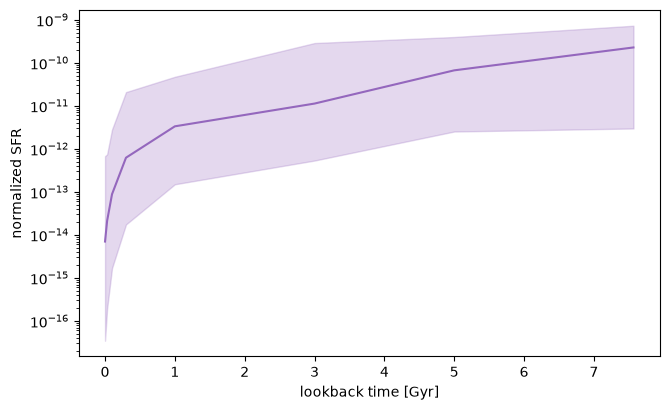

spectrum redshift fixed at 0.6542
spectrum velocity dispersion fixed at 259.5 km/s
spectrum logmass is a slit-aperture normalization


In [14]:
def derived_sfh(result, count=400):
    total = len(result.samples["logsfr_ratios"])
    indices = np.linspace(0, total - 1, min(count, total), dtype=int)
    histories = []
    ages = []
    for index in indices:
        ratios = np.asarray(result.samples["logsfr_ratios"])[index]
        history = np.asarray(
            logsfr_ratios_to_sfh(
                ratios,
                sfh_times_yr=lookback_template * 1e9,
            )
        )
        bin_mass = (
            0.5
            * (history[:-1] + history[1:])
            * np.diff(lookback_template)
            * 1e9
        )
        bin_age = 0.5 * (lookback_template[:-1] + lookback_template[1:])
        histories.append(history)
        ages.append(np.sum(bin_mass * bin_age) / np.sum(bin_mass))
    return np.asarray(histories), np.asarray(ages)


spectrum_histories, spectrum_ages = derived_sfh(spectrum_result)
summary_rows = []
for parameter in ["logmass", "Z", "afe", "diffuse_tau_kc"]:
    q16, q50, q84 = np.percentile(
        spectrum_result.samples[parameter],
        [16, 50, 84],
    )
    summary_rows.append(
        {
            "parameter": parameter,
            "median": q50,
            "minus": q50 - q16,
            "plus": q84 - q50,
        }
    )
q16, q50, q84 = np.percentile(
    np.exp(np.asarray(spectrum_result.samples["log_f_calib"])),
    [16, 50, 84],
)
summary_rows.append(
    {
        "parameter": "fractional calibration floor",
        "median": q50,
        "minus": q50 - q16,
        "plus": q84 - q50,
    }
)
q16, q50, q84 = np.percentile(spectrum_ages, [16, 50, 84])
summary_rows.append(
    {
        "parameter": "mass-weighted age [Gyr]",
        "median": q50,
        "minus": q50 - q16,
        "plus": q84 - q50,
    }
)
display(pd.DataFrame(summary_rows))

q16, q50, q84 = np.percentile(spectrum_histories, [16, 50, 84], axis=0)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(lookback_template, q50, color="tab:purple")
ax.fill_between(lookback_template, q16, q84, color="tab:purple", alpha=0.25)
ax.set(yscale="log", xlabel="lookback time [Gyr]", ylabel="normalized SFR")
plt.show()

print(f"spectrum redshift fixed at {z_catalog:.4f}")
print(f"spectrum velocity dispersion fixed at {sigma_star:.1f} km/s")
print("spectrum logmass is a slit-aperture normalization")

## 13. Interpretation boundary

- fit native pixels using C3K_HR and LEGA-C resolution
- spectroscopy probes features within a limited rest-frame window
- failed sampling diagnostics make the posterior exploratory
- do not propagate this age into H(z) yet